# Modern Portfolio Theory & Value at Risk (VaR) Analysis

This notebook implements two foundational concepts in quantitative finance:

1. **Modern Portfolio Theory (MPT)** — Harry Markowitz's 1952 framework for constructing an *efficient* portfolio that maximizes return for a given level of risk.
2. **Parametric Value at Risk (VaR)** — A statistical measure that answers: *"What is the maximum dollar loss I could expect, at a given confidence level, over a specific time horizon?"*
3. **Monte Carlo Verification** — A simulation-based sanity check that visually confirms the optimizer found the true maximum Sharpe Ratio on the Efficient Frontier.

---
### Portfolio Under Analysis
| Parameter | Value |
|---|---|
| Stocks | AAPL, MSFT, GOOGL, NVDA, AMZN |
| Portfolio Value | $1,000,000 |
| Data Window | Jan 2024 – Jan 2026 (2 years) |
| Risk-Free Rate | 4.0% (annualized) |
| VaR Confidence | 95% |
| Holding Period | 1 Trading Day |

## Part 1 — Setup & Data Collection

We begin by importing the required libraries and fetching two years of daily closing prices from Yahoo Finance.

From the closing prices we compute **log returns**:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are preferred over simple returns in finance because they are:
- **Time-additive**: multi-period returns are just sums of single-period log returns.
- **Symmetric**: gains and losses are treated on the same scale.
- **Approximately normally distributed**: a key assumption for parametric VaR.

In [8]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

# ── Parameters ──────────────────────────────────────────────────────────────
TICKERS = ["AAPL", "MSFT", "GOOGL", "NVDA", "AMZN", "META", "TSLA", "JPM"]
PORTFOLIO_VALUE  = 1_000_000   # USD
RISK_FREE_RATE   = 0.04        # 4% annualized (proxy: US T-Bills)
CONFIDENCE_LEVEL = 0.95        # 95% VaR
TRADING_DAYS     = 252         # Convention for annualization

# ── Fetch historical closing prices ─────────────────────────────────────────
print(f"Downloading data for: {', '.join(TICKERS)} …")
prices = yf.download(TICKERS, start="2024-01-01", end="2026-01-01")["Close"]

# ── Daily log returns ────────────────────────────────────────────────────────
daily_returns = np.log(prices / prices.shift(1)).dropna()

print(f"\nData shape  : {prices.shape}  (rows = trading days, cols = stocks)")
print(f"Returns shape: {daily_returns.shape}")
daily_returns.head()

[                       0%                       ]

[*********************100%***********************]  8 of 8 completed


Data shape  : (502, 8)  (rows = trading days, cols = stocks)
Returns shape: (501, 8)


Ticker,AAPL,AMZN,GOOGL,JPM,META,MSFT,NVDA,TSLA
Date,,,,,,,,
2024-01-03,-0.007516,-0.009786,0.005414,-0.004368,-0.005270,-0.000728,-0.012514,-0.040961
2024-01-04,-0.012782,-0.026619,-0.018380,0.006614,0.007664,-0.007203,0.008978,-0.002183
2024-01-05,-0.004021,0.004624,-0.004851,0.005005,0.013819,-0.000517,0.022639,-0.001851
2024-01-08,0.023887,0.026230,0.022655,-0.001452,0.018886,0.018696,0.062299,0.012387
2024-01-09,-0.002266,0.015110,0.015083,-0.007937,-0.003435,0.002932,0.016833,-0.023097


## Part 2 — Matrix Arithmetic: Annualized Statistics

MPT operates on two key statistical objects derived from the return history:

| Object | Symbol | Formula | Shape |
|---|---|---|---|
| Expected return vector | $\boldsymbol{\mu}$ | $\bar{r}_{daily} \times 252$ | $(5,)$ |
| Covariance matrix | $\boldsymbol{\Sigma}$ | $\text{Cov}_{daily} \times 252$ | $(5 \times 5)$ |

The covariance matrix $\boldsymbol{\Sigma}$ captures how each pair of assets moves together. A low (or negative) covariance between two assets is the mathematical basis for **diversification** — combining them reduces overall portfolio volatility.

In [9]:
# Annualized expected returns vector μ  (shape: 5,)
annual_returns = daily_returns.mean() * TRADING_DAYS

# Annualized covariance matrix Σ  (shape: 5×5)
annual_cov = daily_returns.cov() * TRADING_DAYS

# Daily covariance matrix — used later for single-day VaR
daily_cov = daily_returns.cov()

print("Annualized Expected Returns (μ):")
print((annual_returns * 100).round(2).to_string(), "\n")

print("Annualized Covariance Matrix (Σ) — rounded to 6 dp:")
print(annual_cov.round(6))

Annualized Expected Returns (μ):
Ticker
AAPL     19.66
AMZN     21.70
GOOGL    41.51
JPM      33.79
META     32.80
MSFT     14.10
NVDA     68.12
TSLA     29.85 

Annualized Covariance Matrix (Σ) — rounded to 6 dp:
Ticker      AAPL      AMZN     GOOGL       JPM      META      MSFT      NVDA  \
Ticker                                                                         
AAPL    0.076642  0.041930  0.036853  0.020935  0.038367  0.029012  0.048368   
AMZN    0.041930  0.098103  0.051101  0.030564  0.071929  0.043283  0.080036   
GOOGL   0.036853  0.051101  0.090940  0.021067  0.046398  0.032368  0.061189   
JPM     0.020935  0.030564  0.021067  0.058285  0.026558  0.017782  0.033558   
META    0.038367  0.071929  0.046398  0.026558  0.134932  0.049934  0.085411   
MSFT    0.029012  0.043283  0.032368  0.017782  0.049934  0.048879  0.061506   
NVDA    0.048368  0.080036  0.061189  0.033558  0.085411  0.061506  0.259679   
TSLA    0.076377  0.084864  0.077446  0.055154  0.078193  0.054268

## Part 3 — MPT Optimization: Maximize the Sharpe Ratio

Given a weight vector $\mathbf{w}$ (how much capital to allocate to each stock), the portfolio's key metrics are computed via **matrix multiplication**:

$$\text{Return} = \mathbf{w}^\top \boldsymbol{\mu}$$

$$\text{Volatility} = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}$$

$$\text{Sharpe Ratio} = \frac{\text{Return} - r_f}{\text{Volatility}}$$

The **Sharpe Ratio** measures *risk-adjusted* return — how much excess return you earn per unit of risk. We use `scipy.optimize.minimize` with the **SLSQP** (Sequential Least Squares Programming) algorithm to find the weight vector $\mathbf{w}^*$ that **maximizes** the Sharpe Ratio, subject to:

- **Full investment**: $\sum w_i = 1$
- **No short-selling**: $0 \leq w_i \leq 1$ for all $i$

In [10]:
def portfolio_stats(weights):
    """Return (annualized return, annualized volatility, Sharpe ratio) for a weight vector."""
    weights = np.array(weights)
    port_return = np.dot(weights, annual_returns)
    port_vol    = np.sqrt(weights.T @ annual_cov.values @ weights)
    sharpe      = (port_return - RISK_FREE_RATE) / port_vol
    return port_return, port_vol, sharpe


# scipy minimizes, so we negate the Sharpe Ratio to turn maximization → minimization
def negative_sharpe(weights):
    return -portfolio_stats(weights)[2]


constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}   # weights sum to 1
bounds      = tuple((0, 1) for _ in TICKERS)                    # long-only
init_w      = np.array([1 / len(TICKERS)] * len(TICKERS))       # equal-weight start

print("Running SLSQP optimizer on the Efficient Frontier …")
result     = minimize(negative_sharpe, init_w, method="SLSQP",
                      bounds=bounds, constraints=constraints)
opt_weights = result.x
opt_ret, opt_vol, opt_sharpe = portfolio_stats(opt_weights)

# ── Display results ──────────────────────────────────────────────────────────
print("\n" + "="*52)
print("  OPTIMAL PORTFOLIO ALLOCATIONS (Max Sharpe)")
print("="*52)
for ticker, w in zip(TICKERS, opt_weights):
    bar = "█" * int(w * 40)
    print(f"  {ticker:<6}  {w*100:>6.2f}%  {bar}")
print("-"*52)
print(f"  Expected Annual Return    : {opt_ret*100:.2f}%")
print(f"  Expected Annual Volatility: {opt_vol*100:.2f}%")
print(f"  Maximized Sharpe Ratio    : {opt_sharpe:.4f}")
print("="*52)

Running SLSQP optimizer on the Efficient Frontier …

  OPTIMAL PORTFOLIO ALLOCATIONS (Max Sharpe)
  AAPL      0.00%  
  MSFT      0.00%  
  GOOGL    32.32%  ████████████
  NVDA     47.24%  ██████████████████
  AMZN      0.00%  
  META      0.00%  
  TSLA     20.44%  ████████
  JPM       0.00%  
----------------------------------------------------
  Expected Annual Return    : 43.30%
  Expected Annual Volatility: 23.31%
  Maximized Sharpe Ratio    : 1.6858


## Part 4 — Parametric Value at Risk (VaR)

**VaR** answers: *"What is the maximum loss I should expect to not exceed, at a 95% confidence level, over one trading day?"*

The **Variance-Covariance (parametric)** method assumes portfolio returns are normally distributed. The steps are:

1. Compute the **daily portfolio mean return**: $\mu_p = \mathbf{w}^\top \boldsymbol{\mu}_{daily}$
2. Compute the **daily portfolio volatility**: $\sigma_p = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}_{daily} \mathbf{w}}$
3. Look up the **Z-score** from the inverse normal CDF: $z = \Phi^{-1}(0.95) \approx 1.645$
4. Apply the **VaR formula**:

$$\text{VaR}_{\%} = z \cdot \sigma_p - \mu_p$$

$$\text{VaR}_{\$} = \text{Portfolio Value} \times \text{VaR}_{\%}$$

Subtracting $\mu_p$ gives a more precise boundary by accounting for the portfolio's expected daily drift.

In [11]:
# Daily portfolio statistics using the optimized weights
daily_port_mean = np.dot(opt_weights, daily_returns.mean())
daily_port_std  = np.sqrt(opt_weights.T @ daily_cov.values @ opt_weights)

# Z-score for 95% confidence (one-tailed)
z_score = norm.ppf(CONFIDENCE_LEVEL)

# Parametric VaR
var_pct    = (z_score * daily_port_std) - daily_port_mean
var_dollar = PORTFOLIO_VALUE * var_pct

print("\n" + "="*52)
print("  DAILY RISK ANALYSIS — Parametric VaR")
print("="*52)
print(f"  Portfolio Value           : ${PORTFOLIO_VALUE:>12,.2f}")
print(f"  Confidence Level          : {CONFIDENCE_LEVEL*100:.1f}%")
print(f"  Daily Portfolio Volatility: {daily_port_std*100:.4f}%")
print(f"  Daily Expected Return     : {daily_port_mean*100:.4f}%")
print(f"  Z-Score (N⁻¹(0.95))       : {z_score:.4f}")
print("-"*52)
print(f"  VaR (%)                   : {var_pct*100:.4f}%")
print(f"  VaR ($)                   : ${var_dollar:>12,.2f}")
print("="*52)
print(f"\n  → There is a {CONFIDENCE_LEVEL*100:.0f}% probability that this portfolio")
print(f"    will NOT lose more than ${var_dollar:,.2f} in a single trading day.")
print("="*52)


  DAILY RISK ANALYSIS — Parametric VaR
  Portfolio Value           : $1,000,000.00
  Confidence Level          : 95.0%
  Daily Portfolio Volatility: 1.4686%
  Daily Expected Return     : 0.1718%
  Z-Score (N⁻¹(0.95))       : 1.6449
----------------------------------------------------
  VaR (%)                   : 2.2439%
  VaR ($)                   : $   22,438.61

  → There is a 95% probability that this portfolio
    will NOT lose more than $22,438.61 in a single trading day.


## Part 5 — Monte Carlo Verification of the Efficient Frontier

Before trusting the optimizer's output, we **verify it independently** using a Monte Carlo simulation.

The idea is simple: generate **25,000 random weight combinations**, compute the (return, volatility, Sharpe) for each, and plot them. The resulting cloud of points traces out the **Efficient Frontier** — the set of portfolios offering the best possible return for each level of risk.

If the SLSQP optimizer worked correctly, the red star (its solution) should sit at the **tip** of the frontier — above and to the left of all random simulations.

> **Interpretation of color map**: Each point is colored by its Sharpe Ratio. Yellower = higher Sharpe = better risk-adjusted return. The optimizer's point should be the brightest (or very close to it).

In [12]:
NUM_PORTFOLIOS = 25_000
np.random.seed(42)   # reproducibility

mc_vols, mc_rets, mc_sharpes = [], [], []

for _ in range(NUM_PORTFOLIOS):
    w = np.random.random(len(TICKERS))
    w /= w.sum()                          # normalize so weights sum to 1
    p_ret, p_vol, p_sharpe = portfolio_stats(w)
    mc_vols.append(p_vol)
    mc_rets.append(p_ret)
    mc_sharpes.append(p_sharpe)

mc_vols    = np.array(mc_vols)
mc_rets    = np.array(mc_rets)
mc_sharpes = np.array(mc_sharpes)

best_mc_sharpe = mc_sharpes.max()
print(f"Optimizer Sharpe  : {opt_sharpe:.5f}")
print(f"Best Random Sharpe: {best_mc_sharpe:.5f}")
print(f"Optimizer wins by : {opt_sharpe - best_mc_sharpe:.5f}  ✓" if opt_sharpe >= best_mc_sharpe
      else f"Warning — a random portfolio beat the optimizer!")

Optimizer Sharpe  : 1.68582
Best Random Sharpe: 1.54329
Optimizer wins by : 0.14253  ✓


### 5.1 — Plot: Efficient Frontier & Maximum Sharpe Portfolio

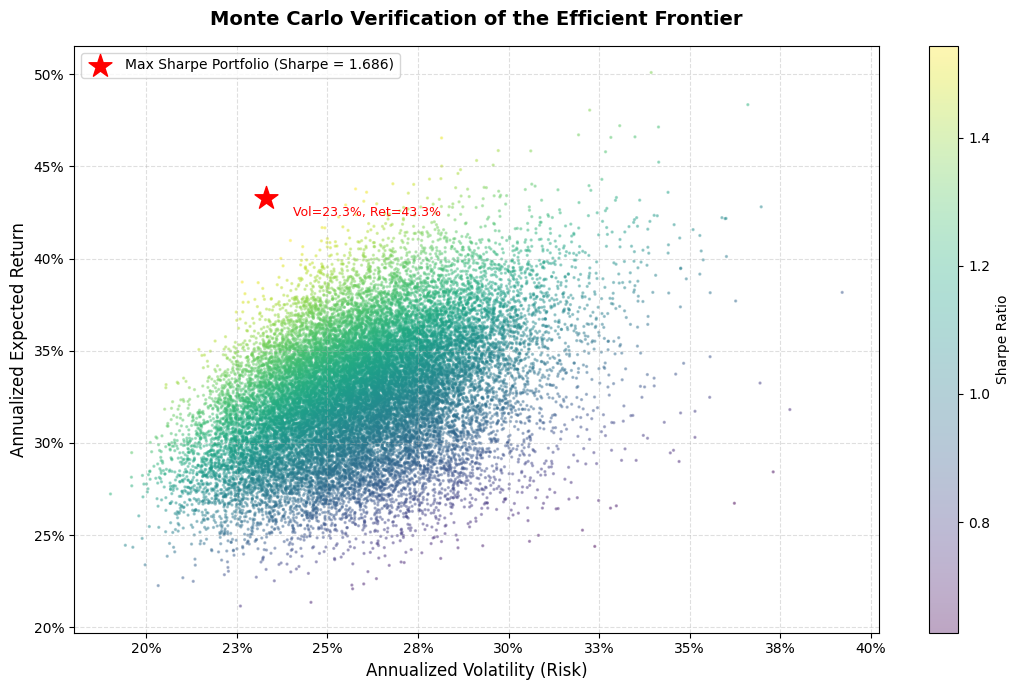

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))

# 25,000 random portfolios — color-coded by Sharpe Ratio
sc = ax.scatter(mc_vols, mc_rets,
                c=mc_sharpes, cmap="viridis",
                s=2, alpha=0.35, zorder=1)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")

# Optimizer result — the Maximum Sharpe Portfolio
ax.scatter(opt_vol, opt_ret,
           color="red", marker="*", s=300, zorder=5,
           label=f"Max Sharpe Portfolio (Sharpe = {opt_sharpe:.3f})")

# Annotate the star
ax.annotate(f"  Vol={opt_vol*100:.1f}%, Ret={opt_ret*100:.1f}%",
            xy=(opt_vol, opt_ret), fontsize=9, color="red",
            xytext=(opt_vol + 0.005, opt_ret - 0.01))

ax.set_title("Monte Carlo Verification of the Efficient Frontier",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Annualized Volatility (Risk)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 6 — Summary Dashboard

A consolidated view of the final outputs from both the MPT optimizer and the VaR model.

In [14]:
summary = pd.DataFrame({
    "Ticker"             : TICKERS,
    "Optimal Weight (%)" : (opt_weights * 100).round(2),
    "Exp. Ann. Return (%)" : (annual_returns.values * 100).round(2),
    "Ann. Volatility (%)" : (np.sqrt(np.diag(annual_cov.values)) * 100).round(2),
}).set_index("Ticker")

print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)
print(summary.to_string())
print("-"*60)
print(f"  Optimal Portfolio Return      : {opt_ret*100:.2f}%")
print(f"  Optimal Portfolio Volatility  : {opt_vol*100:.2f}%")
print(f"  Maximized Sharpe Ratio        : {opt_sharpe:.4f}")
print("-"*60)
print(f"  95% 1-Day Parametric VaR (%)  : {var_pct*100:.4f}%")
print(f"  95% 1-Day Parametric VaR ($)  : ${var_dollar:,.2f}")
print("="*60)


  FINAL SUMMARY
        Optimal Weight (%)  Exp. Ann. Return (%)  Ann. Volatility (%)
Ticker                                                               
AAPL                  0.00                 19.66                27.68
MSFT                  0.00                 21.70                31.32
GOOGL                32.32                 41.51                30.16
NVDA                 47.24                 33.79                24.14
AMZN                  0.00                 32.80                36.73
META                  0.00                 14.10                22.11
TSLA                 20.44                 68.12                50.96
JPM                   0.00                 29.85                62.87
------------------------------------------------------------
  Optimal Portfolio Return      : 43.30%
  Optimal Portfolio Volatility  : 23.31%
  Maximized Sharpe Ratio        : 1.6858
------------------------------------------------------------
  95% 1-Day Parametric VaR (%)  : 2.24

---
## Key Takeaways

| Concept | What It Tells You |
|---|---|
| **Optimal Weights** | The exact capital allocation that produces the highest risk-adjusted return |
| **Sharpe Ratio** | Units of excess return earned per unit of risk taken |
| **VaR ($)** | The maximum expected daily dollar loss at 95% confidence |
| **Monte Carlo** | Visual proof that the optimizer found the global optimum on the frontier |

### Limitations to be aware of
- **Parametric VaR assumes normality** — real returns have fat tails (kurtosis). Consider Historical Simulation or CVaR for a more conservative estimate.
- **MPT is backward-looking** — the optimizer uses historical returns, which may not persist.
- **No transaction costs or taxes** — in practice these erode the theoretical Sharpe Ratio.